In [ ]:
from huggingface_hub import notebook_login
from google.colab import userdata

# Log in to Hugging Face using the token stored in Colab secrets
notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

Accuracy: 38.29% | F1 Score: 55.37% | Solve Rate: 49.43%

=== Evaluating: Few Shot ===


Running Inference: 100%|██████████| 44/44 [1:18:11<00:00, 106.63s/it]


Accuracy: 1.71% | F1 Score: 3.37% | Solve Rate: 100.00%

=== Evaluating: Cot ===


Running Inference: 100%|██████████| 44/44 [1:15:06<00:00, 102.41s/it]


Accuracy: 33.14% | F1 Score: 49.79% | Solve Rate: 82.57%


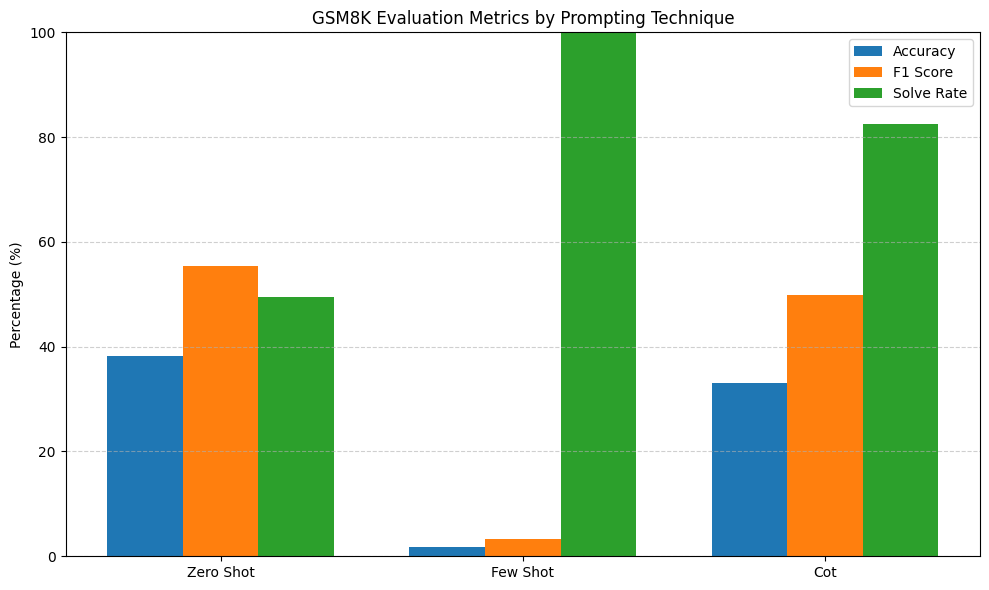

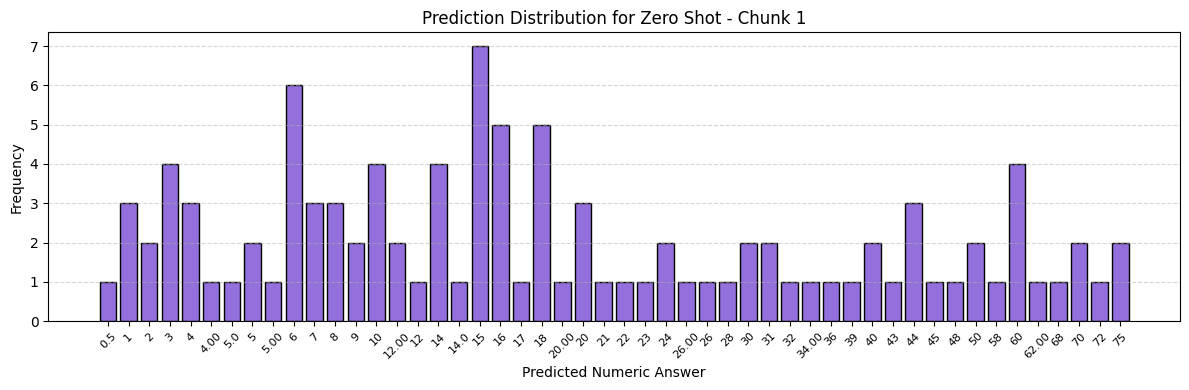

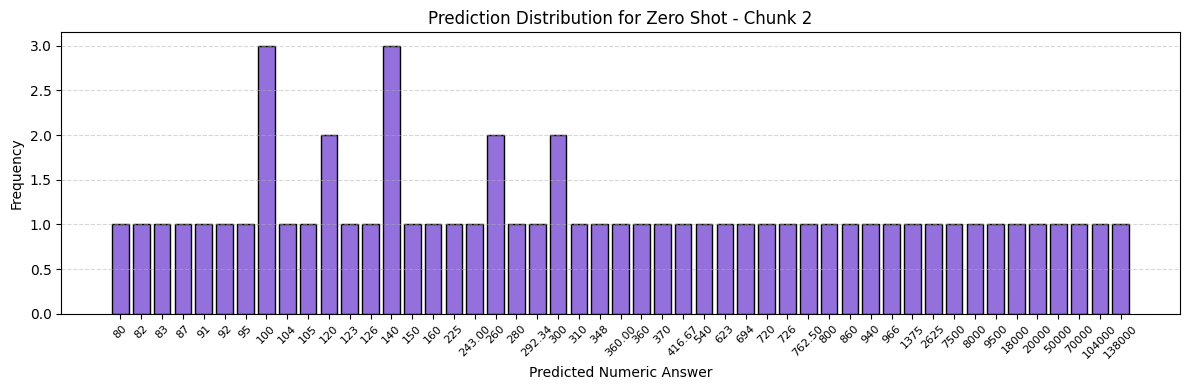

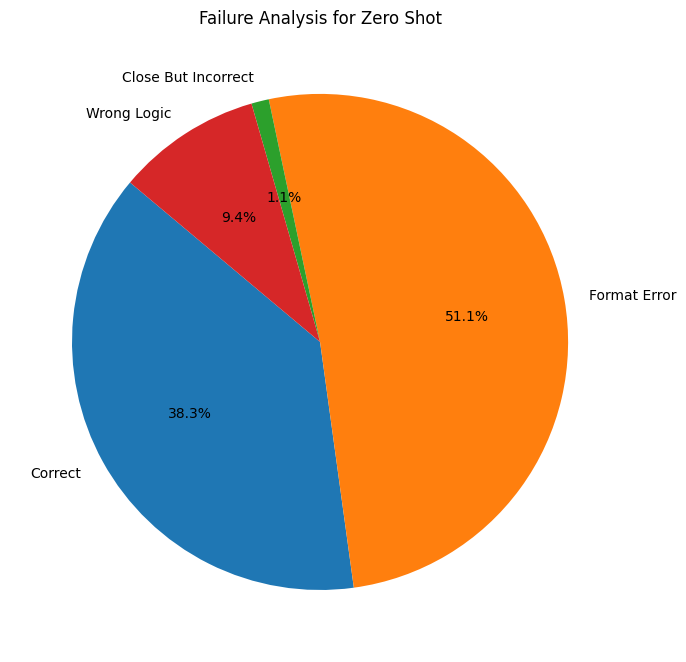

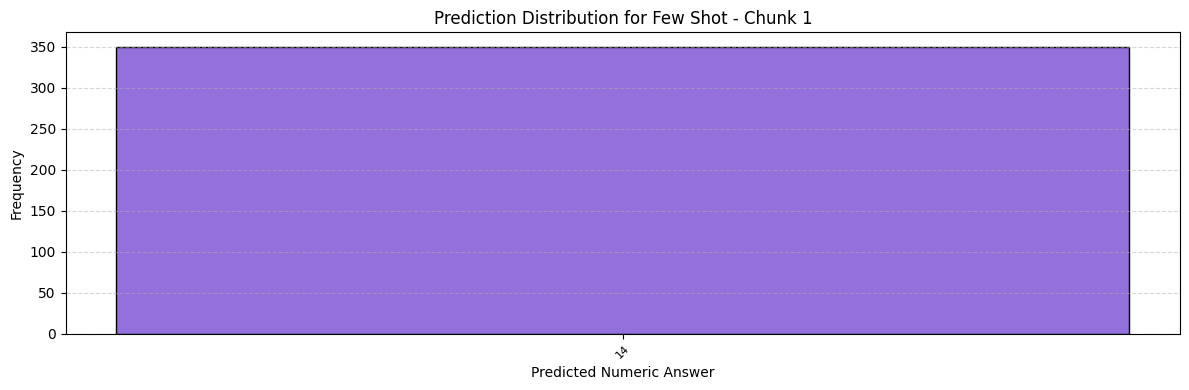

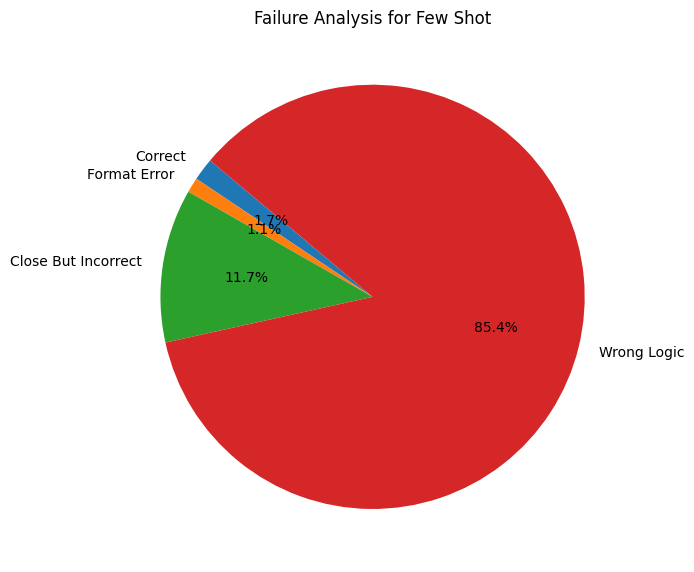

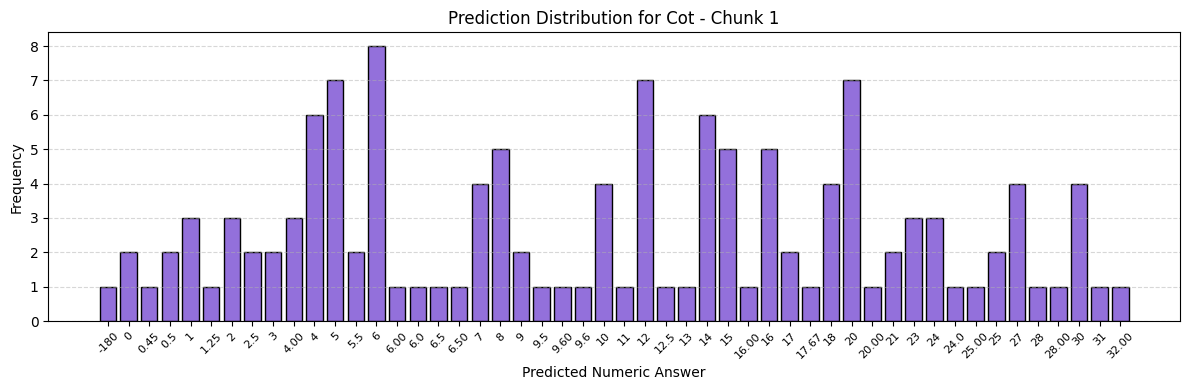

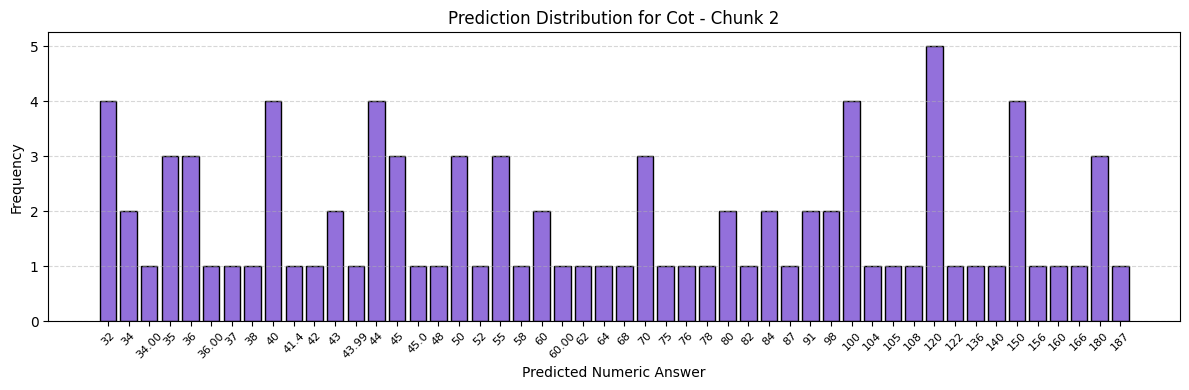

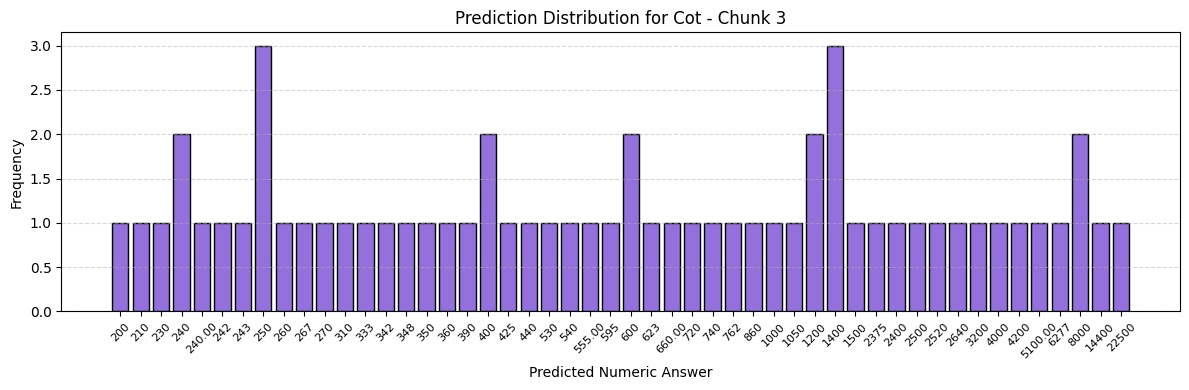

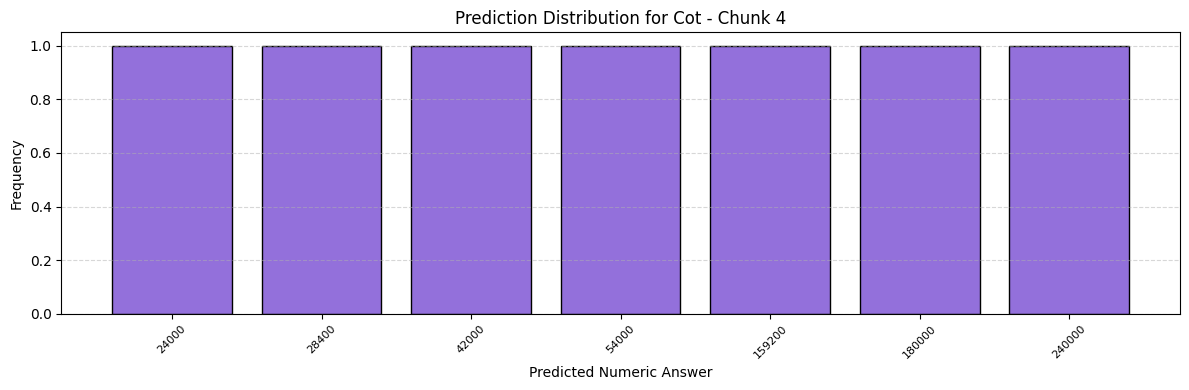

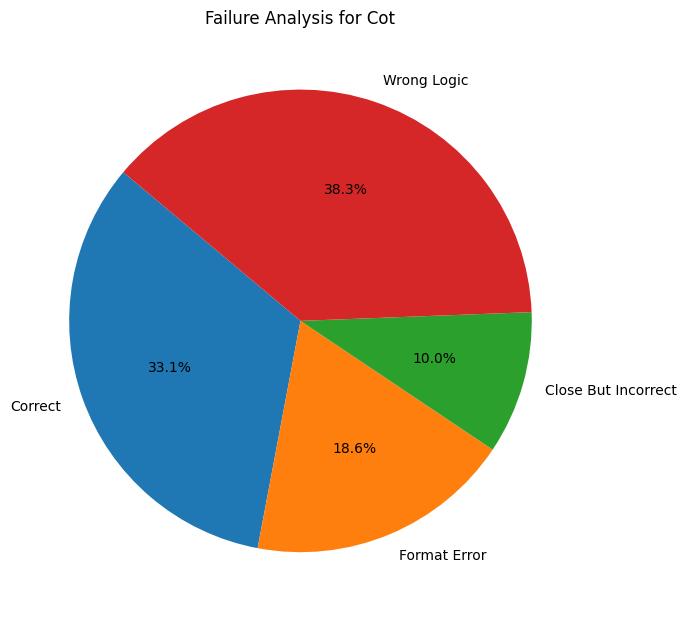

In [ ]:
# === [1] Install Required Libraries ===
!pip install -q transformers datasets accelerate bitsandbytes peft
!pip install --upgrade datasets transformers

# === [2] Imports ===
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, pipeline
)
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np
import re

# === [3] Model Configuration ===
model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.float16
)

text_generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=164,
    temperature=0.2,
    pad_token_id=tokenizer.eos_token_id
)

# === [4] Load GSM8K Test Subset ===
gsm8k = load_dataset("gsm8k", "main")
test_data = gsm8k["test"].select(range(650))
test_samples = [{"question": row["question"], "answer": row["answer"]} for row in test_data]

# === [5] Few-Shot Prompt Examples ===
optimized_few_shot_examples = [
    {
        "question": "Alice has 5 boxes. Each box contains 4 pencils. She gives 6 pencils to her friend. How many does she have left?",
        "answer": "5 boxes * 4 pencils = 20 pencils. She gives away 6. 20 - 6 = 14.\n#### 14"
    },
    {
        "question": "A concert ticket costs $15. Jack buys 4 tickets and pays with a $100 bill. How much change does he get?",
        "answer": "4 tickets * $15 = $60. $100 - $60 = $40.\n#### 40"
    },
    {
        "question": "There are 6 rows of chairs with 10 chairs in each row. If 8 chairs are broken, how many usable chairs are there?",
        "answer": "6 * 10 = 60 chairs. 60 - 8 = 52.\n#### 52"
    }
]

# === [6] Prompt Templates ===
def optimized_zero_shot_prompt(example):
    return (
        "You are a math expert. Solve the following word problem step-by-step.\n"
        "Finish with the final answer using the format: #### <number>\n\n"
        f"Q: {example['question']}\nA:"
    )

def optimized_few_shot_prompt(example):
    prompt = (
        "You are a math expert. Solve each problem and provide only the final answer.\n"
        "Format your final answer as: #### <number>\n\n"
    )
    for ex in optimized_few_shot_examples:
        prompt += f"Q: {ex['question']}\nA: {ex['answer']}\n\n"
    prompt += f"Q: {example['question']}\nA:"
    return prompt

def improved_cot_prompt(example):
    return (
        "You are a math reasoning expert.\n"
        "Break down the problem clearly and logically, using one step per line.\n"
        "At the end, provide your final answer on a new line using this format: #### <number>\n\n"
        f"Q: {example['question']}\nA:"
    )

# === [7] Prompt Construction ===
def build_prompts_for_all_techniques(samples, technique):
    prompts, true_answers = [], []
    for sample in samples:
        if technique == "zero_shot":
            prompt = optimized_zero_shot_prompt(sample)
        elif technique == "few_shot":
            prompt = optimized_few_shot_prompt(sample)
        elif technique == "cot":
            prompt = improved_cot_prompt(sample)
        else:
            raise ValueError("Unsupported technique.")
        prompts.append(prompt)
        true_answers.append(sample["answer"].split("####")[-1].strip())
    return prompts, true_answers

# === [8] Answer Extraction ===
def extract_predicted_answer(text):
    match = re.search(r"####\s*([-\d,.]+)", text)
    return match.group(1).replace(",", "") if match else "N/A"

# === [9] Evaluation Function ===
def run_inference_with_metrics(prompts, true_answers, generator, batch_size=8):
    model_answers, correct_flags, solved_flags = [], [], []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Running Inference"):
        batch = prompts[i:i + batch_size]
        outputs = generator(batch)

        for output, true_ans in zip(outputs, true_answers[i:i + batch_size]):
            generated = output[0]['generated_text']
            pred = extract_predicted_answer(generated)
            model_answers.append(pred)

            try:
                correct = abs(float(pred) - float(true_ans)) < 1e-4
                solved = True
            except:
                correct = False
                solved = pred.strip().isdigit()

            correct_flags.append(correct)
            solved_flags.append(solved)

    accuracy = sum(correct_flags) / len(correct_flags)
    solve_rate = sum(solved_flags) / len(solved_flags)
    f1 = f1_score([1] * len(correct_flags), [1 if x else 0 for x in correct_flags])
    return accuracy * 100, f1 * 100, solve_rate * 100, correct_flags, model_answers

# === [10] Full Evaluation for All Techniques ===
def evaluate_all_final_techniques(samples, generator):
    techniques = ["zero_shot", "few_shot", "cot"]
    results_summary = {}

    for tech in techniques:
        print(f"\n=== Evaluating: {tech.replace('_', ' ').title()} ===")
        prompts, answers = build_prompts_for_all_techniques(samples, tech)
        accuracy, f1, solve_rate, correct_flags, predictions = run_inference_with_metrics(prompts, answers, generator)

        results_summary[tech] = {
            "accuracy": accuracy,
            "f1": f1,
            "solve_rate": solve_rate,
            "correct_flags": correct_flags,
            "model_answers": predictions,
            "true_answers": answers
        }

        print(f"Accuracy: {accuracy:.2f}% | F1 Score: {f1:.2f}% | Solve Rate: {solve_rate:.2f}%")

    return results_summary

# === [11] Run All Evaluations for GSM8K ===
results_summary = evaluate_all_final_techniques(test_samples, text_generator)

# === [12] Bar Chart: Accuracy, F1 Score, Solve Rate ===
def plot_gsm8k_results(results_summary):
    techniques = list(results_summary.keys())
    accuracy = [results_summary[t]["accuracy"] for t in techniques]
    f1_score_vals = [results_summary[t]["f1"] for t in techniques]
    solve_rate = [results_summary[t]["solve_rate"] for t in techniques]

    x = np.arange(len(techniques))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, accuracy, width, label='Accuracy')
    plt.bar(x, f1_score_vals, width, label='F1 Score')
    plt.bar(x + width, solve_rate, width, label='Solve Rate')

    plt.ylabel("Percentage (%)")
    plt.title("GSM8K Evaluation Metrics by Prompting Technique")
    plt.xticks(x, [t.replace("_", " ").title() for t in techniques])
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# === [13] Prediction Distribution (Sorted & Clean) ===
def plot_prediction_distribution(results_summary, technique, chunk_size=50):
    predictions = results_summary[technique]["model_answers"]
    numeric_preds = [p for p in predictions if re.match(r"^-?\d+(\.\d+)?$", p)]

    if not numeric_preds:
        print(f"No numeric predictions found for {technique}.")
        return

    counts = Counter(numeric_preds)
    sorted_counts = dict(sorted(counts.items(), key=lambda x: float(x[0])))

    x_vals = list(sorted_counts.keys())
    y_vals = list(sorted_counts.values())

    # Chunked visualization
    num_chunks = (len(x_vals) + chunk_size - 1) // chunk_size
    for i in range(num_chunks):
        start = i * chunk_size
        end = start + chunk_size
        chunk_x = x_vals[start:end]
        chunk_y = y_vals[start:end]

        plt.figure(figsize=(12, 4))
        plt.bar(chunk_x, chunk_y, color='mediumpurple', edgecolor='black')
        plt.title(f"Prediction Distribution for {technique.replace('_', ' ').title()} - Chunk {i+1}")
        plt.xlabel("Predicted Numeric Answer")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, fontsize=8)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


# === [14] Failure Analysis Pie Chart ===
def plot_failure_analysis_pie(results_summary, technique):
    predictions = results_summary[technique]["model_answers"]
    true_answers = results_summary[technique]["true_answers"]

    categories = {
        "Correct": 0,
        "Format Error": 0,
        "Close But Incorrect": 0,
        "Wrong Logic": 0
    }

    for pred, true in zip(predictions, true_answers):
        try:
            pred_val = float(pred)
            true_val = float(true)
            if abs(pred_val - true_val) < 1e-4:
                categories["Correct"] += 1
            elif abs(pred_val - true_val) < 5:
                categories["Close But Incorrect"] += 1
            else:
                categories["Wrong Logic"] += 1
        except:
            categories["Format Error"] += 1

    plt.figure(figsize=(7, 7))
    plt.pie(categories.values(), labels=categories.keys(), autopct='%1.1f%%', startangle=140)
    plt.title(f"Failure Analysis for {technique.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

plot_gsm8k_results(results_summary)

for technique in ["zero_shot", "few_shot", "cot"]:
    plot_prediction_distribution(results_summary, technique)
    plot_failure_analysis_pie(results_summary, technique)
